# **EXECUTIVE SUMMARY**
- This project focuses on unsupervised machine learning to analyze public sentiment and thematic structures within the Twitter US Airline Sentiment dataset and the 20 Newsgroups collection. The primary use case is to automate the categorization of large-scale textual data to help organizations understand customer grievances and information trends without manual labeling.

- Preprocessing involved extensive Natural Language Processing (NLP) techniques, including the removal of stop words, punctuation, and handles, followed by WordNet lemmatization to reduce words to their base forms. For model development, I implemented Latent Dirichlet Allocation (LDA) using scikit-learn to extract latent topics from the documents.

- The analysis revealed distinct clusters, such as airline service complaints (delays, baggage) and technical hardware discussions (SCSI, VLB cards). While the LDA model provided a solid foundation for topic discovery, it was not entirely satisfactory due to overlapping terms between topics, suggesting a need for finer hyperparameter tuning. To address the use case effectively, the model identifies specific pain points in customer feedback. If performance remains sub-optimal, the next steps should include experimenting with Non-Negative Matrix Factorization (NMF) or BERT-based embeddings to capture deeper semantic relationships and improve cluster separation.

In [1]:
!python --version

Python 3.9.19


In [2]:
import warnings
warnings.filterwarnings('ignore')

# Importing the require libraries for this project

In [3]:
import langdetect  # language detection
import matplotlib.pyplot  # plotting
import nltk  # natural language processing
import numpy  # arrays and matrices
import pandas  # dataframes
import pyLDAvis  # plotting
from pyLDAvis.lda_model import prepare

# import pyLDAvis.sklearn
from pyLDAvis import lda_model
# ...
import regex  # regular expressions
import sklearn  # machine learning

In [4]:
# define some global variables

number_words = 10
number_docs = 10
number_features = 1000

In [5]:
import sys
sys.setrecursionlimit(10000)

In [6]:
# installing specific word dictionarys
# used for stopword removal and lemmatization

nltk.download('wordnet')
nltk.download('stopwords')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\folaitan\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\folaitan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [7]:
# define path and load data

path = "Tweets.csv"
df = pandas.read_csv(path, header=0)

In [8]:
# define quick look function for data frame

def dataframe_quick_look(df, nrows):
    print("SHAPE:\n{shape}\n".format(shape=df.shape))
    print("COLUMN NAMES:\n{names}\n".format(names=df.columns))
    print("HEAD:\n{head}\n".format(head=df.head(nrows)))

In [9]:
dataframe_quick_look(df, nrows=2)

SHAPE:
(14640, 15)

COLUMN NAMES:
Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='object')

HEAD:
             tweet_id airline_sentiment  airline_sentiment_confidence  \
0  570306133677760513           neutral                        1.0000   
1  570301130888122368          positive                        0.3486   

  negativereason  negativereason_confidence         airline  \
0            NaN                        NaN  Virgin America   
1            NaN                        0.0  Virgin America   

  airline_sentiment_gold      name negativereason_gold  retweet_count  \
0                    NaN   cairdin                 NaN              0   
1                    NaN  jnardino                 NaN              0   


In [10]:
from sklearn.datasets import fetch_20newsgroups

In [11]:
docs = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))['data']

In [12]:
# docs

#### **Text Preprocessing Strategy**
To ensure high-quality topic discovery, we implemented a standardized preprocessing pipeline.

#### **Why Lemmatization?**
We specifically chose WordNet Lemmatization over Stemming. While stemming simply chops off word endings (e.g., "flying" becomes "fli"), lemmatization uses a vocabulary and morphological analysis to return the word to its base dictionary form (e.g., "flying" becomes "fly"). This preserves the semantic meaning and context of the words, which is crucial for stakeholders to interpret the resulting topics accurately.

#### **Cleaning Logic:**

Regex Stripping: Removed Twitter-specific noise like @mentions and URLs that do not contribute to thematic content.

Noise Reduction: Filtered out "stop words" and tokens shorter than 3 characters to remove non-informative data.

In [13]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
import re

# Initialize toolkits
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # 1. Regex cleaning: Remove handles (@user), URLs, and non-alphabetical characters
    text = re.sub(r'@\w+|http\S+|[^a-zA-Z\s]', '', str(text).lower())
    
    # 2. Tokenization & Stop word removal
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    
    # 3. Lemmatization: Reduce words to their base dictionary form
    lemmatized_output = [lemmatizer.lemmatize(w) for w in tokens]
    
    return " ".join(lemmatized_output)

# Apply to Twitter Data
df['clean_tweet'] = df['text'].apply(clean_text)

# Apply to Newsgroups Data (convert list to Series first for ease of use)
clean_docs = [clean_text(d) for d in docs]

# Quick look at the result
print("Original:", df['text'].iloc[1])
print("Cleaned:", df['clean_tweet'].iloc[1])

Original: @VirginAmerica plus you've added commercials to the experience... tacky.
Cleaned: plus youve added commercial experience tacky


In [14]:
# put my doc into a pandas dataframe
df = pandas.DataFrame(docs, columns=['text'])

In [15]:
df

,text
0,\n\nI am sure some bashers of Pens fans are pr...
1,My brother is in the market for a high-perform...
2,\n\n\n\n\tFinally you said what you dream abou...
3,\nThink!\n\nIt's the SCSI card doing the DMA t...
4,1) I have an old Jasmine drive which I cann...
...,...
18841,DN> From: nyeda@cnsvax.uwec.edu (David Nye)\nD...
18842,\nNot in isolated ground recepticles (usually ...
18843,I just installed a DX2-66 CPU in a clone mothe...
18844,\nWouldn't this require a hyper-sphere. In 3-...


In [16]:
# lets look at the final data we are going to move forward with

raw = df["text"].tolist()
print("HEADLINES:\n{lines}\n".format(lines=raw[:5]))
print("LENGTH:\n{length}\n".format(length=len(raw)))

HEADLINES:
["\n\nI am sure some bashers of Pens fans are pretty confused about the lack\nof any kind of posts about the recent Pens massacre of the Devils. Actually,\nI am  bit puzzled too and a bit relieved. However, I am going to put an end\nto non-PIttsburghers' relief with a bit of praise for the Pens. Man, they\nare killing those Devils worse than I thought. Jagr just showed you why\nhe is much better than his regular season stats. He is also a lot\nfo fun to watch in the playoffs. Bowman should let JAgr have a lot of\nfun in the next couple of games since the Pens are going to beat the pulp out of Jersey anyway. I was very disappointed not to see the Islanders lose the final\nregular season game.          PENS RULE!!!\n\n", 'My brother is in the market for a high-performance video card that supports\nVESA local bus with 1-2MB RAM.  Does anyone have suggestions/ideas on:\n\n  - Diamond Stealth Pro Local Bus\n\n  - Orchid Farenheit 1280\n\n  - ATI Graphics Ultra Pro\n\n  - Any othe

In [17]:
# select one headline to use as an example

example = df['text'].iloc[5]
print(example)



Back in high school I worked as a lab assistant for a bunch of experimental
psychologists at Bell Labs.  When they were doing visual perception and
memory experiments, they used vector-type displays, with 1-millisecond
refresh rates common.

So your case of 1/200th sec is quite practical, and the experimenters were
probably sure that it was 5 milliseconds, not 4 or 6 either.


Steve


In [18]:
# check language of headline
# filter to english only

def do_language_identifying(txt):
    try: the_language = langdetect.detect(txt)
    except: the_language = 'none'
    return the_language

In [19]:
print("DETECTED LANGUAGE:\n{lang}\n".format(lang=do_language_identifying(example)))

DETECTED LANGUAGE:
en



In [20]:
# tokenize the data

example = example.split(" ")
print(example)

['\n\nBack', 'in', 'high', 'school', 'I', 'worked', 'as', 'a', 'lab', 'assistant', 'for', 'a', 'bunch', 'of', 'experimental\npsychologists', 'at', 'Bell', 'Labs.', '', 'When', 'they', 'were', 'doing', 'visual', 'perception', 'and\nmemory', 'experiments,', 'they', 'used', 'vector-type', 'displays,', 'with', '1-millisecond\nrefresh', 'rates', 'common.\n\nSo', 'your', 'case', 'of', '1/200th', 'sec', 'is', 'quite', 'practical,', 'and', 'the', 'experimenters', 'were\nprobably', 'sure', 'that', 'it', 'was', '5', 'milliseconds,', 'not', '4', 'or', '6', 'either.\n\n\nSteve']


In [21]:
# remove punctuation

example = [regex.sub("[^\\w\\s]|\n", "", i) for i in example]
print(example)

['Back', 'in', 'high', 'school', 'I', 'worked', 'as', 'a', 'lab', 'assistant', 'for', 'a', 'bunch', 'of', 'experimentalpsychologists', 'at', 'Bell', 'Labs', '', 'When', 'they', 'were', 'doing', 'visual', 'perception', 'andmemory', 'experiments', 'they', 'used', 'vectortype', 'displays', 'with', '1millisecondrefresh', 'rates', 'commonSo', 'your', 'case', 'of', '1200th', 'sec', 'is', 'quite', 'practical', 'and', 'the', 'experimenters', 'wereprobably', 'sure', 'that', 'it', 'was', '5', 'milliseconds', 'not', '4', 'or', '6', 'eitherSteve']


In [22]:
# remove numbers

example = [regex.sub("^[0-9]*$", "", i) for i in example]
print(example)

['Back', 'in', 'high', 'school', 'I', 'worked', 'as', 'a', 'lab', 'assistant', 'for', 'a', 'bunch', 'of', 'experimentalpsychologists', 'at', 'Bell', 'Labs', '', 'When', 'they', 'were', 'doing', 'visual', 'perception', 'andmemory', 'experiments', 'they', 'used', 'vectortype', 'displays', 'with', '1millisecondrefresh', 'rates', 'commonSo', 'your', 'case', 'of', '1200th', 'sec', 'is', 'quite', 'practical', 'and', 'the', 'experimenters', 'wereprobably', 'sure', 'that', 'it', 'was', '', 'milliseconds', 'not', '', 'or', '', 'eitherSteve']


In [23]:
# make everything lowercase

example = [i.lower() if i not in ["URL"] else i for i in example]
print(example)

['back', 'in', 'high', 'school', 'i', 'worked', 'as', 'a', 'lab', 'assistant', 'for', 'a', 'bunch', 'of', 'experimentalpsychologists', 'at', 'bell', 'labs', '', 'when', 'they', 'were', 'doing', 'visual', 'perception', 'andmemory', 'experiments', 'they', 'used', 'vectortype', 'displays', 'with', '1millisecondrefresh', 'rates', 'commonso', 'your', 'case', 'of', '1200th', 'sec', 'is', 'quite', 'practical', 'and', 'the', 'experimenters', 'wereprobably', 'sure', 'that', 'it', 'was', '', 'milliseconds', 'not', '', 'or', '', 'eithersteve']


In [24]:
# remove the 1200th from the text
example = [i for i in example if i not in ["1200th", "1", ""]]
print(example)

['back', 'in', 'high', 'school', 'i', 'worked', 'as', 'a', 'lab', 'assistant', 'for', 'a', 'bunch', 'of', 'experimentalpsychologists', 'at', 'bell', 'labs', 'when', 'they', 'were', 'doing', 'visual', 'perception', 'andmemory', 'experiments', 'they', 'used', 'vectortype', 'displays', 'with', '1millisecondrefresh', 'rates', 'commonso', 'your', 'case', 'of', 'sec', 'is', 'quite', 'practical', 'and', 'the', 'experimenters', 'wereprobably', 'sure', 'that', 'it', 'was', 'milliseconds', 'not', 'or', 'eithersteve']


In [25]:
# remove stopwords
# uses stopwords dictionary previously loaded

list_stop_words = nltk.corpus.stopwords.words("English")
list_stop_words = [regex.sub("[^\\w\\s]", "", i) for i in list_stop_words]
print(list_stop_words)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', 'arent', 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', 'couldnt', 'd', 'did', 'didn', 'didnt', 'do', 'does', 'doesn', 'doesnt', 'doing', 'don', 'dont', 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', 'hadnt', 'has', 'hasn', 'hasnt', 'have', 'haven', 'havent', 'having', 'he', 'hed', 'hell', 'her', 'here', 'hers', 'herself', 'hes', 'him', 'himself', 'his', 'how', 'i', 'id', 'if', 'ill', 'im', 'in', 'into', 'is', 'isn', 'isnt', 'it', 'itd', 'itll', 'its', 'its', 'itself', 'ive', 'just', 'll', 'm', 'ma', 'me', 'mightn', 'mightnt', 'more', 'most', 'mustn', 'mustnt', 'my', 'myself', 'needn', 'neednt', 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', 'shant', 'she', 'shed', 'shell', 'sh

In [26]:
example = [i for i in example if i not in list_stop_words]
print(example)

['back', 'high', 'school', 'worked', 'lab', 'assistant', 'bunch', 'experimentalpsychologists', 'bell', 'labs', 'visual', 'perception', 'andmemory', 'experiments', 'used', 'vectortype', 'displays', '1millisecondrefresh', 'rates', 'commonso', 'case', 'sec', 'quite', 'practical', 'experimenters', 'wereprobably', 'sure', 'milliseconds', 'eithersteve']


In [27]:
# perform lemmatization
# uses wordnet dictionary previously loaded

def do_lemmatizing(wrd):
    out = nltk.corpus.wordnet.morphy(wrd)
    return (wrd if out is None else out)

In [28]:
example = [do_lemmatizing(i) for i in example]
print(example)

['back', 'high', 'school', 'work', 'lab', 'assistant', 'bunch', 'experimentalpsychologists', 'bell', 'lab', 'visual', 'perception', 'andmemory', 'experiment', 'use', 'vectortype', 'display', '1millisecondrefresh', 'rates', 'commonso', 'case', 'sec', 'quite', 'practical', 'experimenter', 'wereprobably', 'sure', 'millisecond', 'eithersteve']


In [29]:
# remove words less than 5 characters long

example = [i for i in example if len(i) >= 5]
print(example)

['school', 'assistant', 'bunch', 'experimentalpsychologists', 'visual', 'perception', 'andmemory', 'experiment', 'vectortype', 'display', '1millisecondrefresh', 'rates', 'commonso', 'quite', 'practical', 'experimenter', 'wereprobably', 'millisecond', 'eithersteve']


In [30]:
# define consolidated data cleaning function

def do_headline_cleaning(txt):
    # identify language of tweet
    # return null if language not english
    lg = do_language_identifying(txt)
    if lg != 'en':
        return None
    
    # split the string on whitespace
    out = txt.split(" ")
    
    # identify urls
    # replace with URL
    out = ['URL' if bool(regex.search("http[s]?://", i)) else i for i in out]
    
    # remove all punctuation
    out = [regex.sub("[^\\w\\s]|\n", "", i) for i in out]
    
    # remove all numerics
    out = [regex.sub("^[0-9]*$", "", i) for i in out]
    
    # make all non-keywords lowercase
    out = [i.lower() if i not in ["URL"] else i for i in out]
    
    # remove URL
    out = [i for i in out if i not in ["URL",""]]
    
    # remove stopwords
    list_stop_words = nltk.corpus.stopwords.words("english")
    list_stop_words = [regex.sub("[^\\w\\s]", "", i) for i in list_stop_words]
    
    out = [i for i in out if i not in list_stop_words]
    
    # lemmatizing
    out = [do_lemmatizing(i) for i in out]
    
    # keep words 5 or more characters long
    out = [i for i in out if len(i) >= 5]
    
    return out

from time import time

In [31]:
# execute function
# takes several minutes
tick = time()
clean = list(map(do_headline_cleaning, raw))
print(time()-tick)

255.15018248558044


In [32]:
# remove none types

clean = list(filter(None.__ne__, clean))
print("HEADLINES:\n{lines}\n".format(lines=clean[:5]))
print("LENGTH:\n{length}\n".format(length=len(clean)))

HEADLINES:
[['bashers', 'pretty', 'confuse', 'lackof', 'recent', 'massacre', 'devil', 'actuallyi', 'puzzle', 'relieve', 'however', 'going', 'endto', 'nonpittsburghers', 'relief', 'praise', 'theyare', 'killing', 'devil', 'worse', 'thought', 'whyhe', 'better', 'regular', 'season', 'stats', 'lotfo', 'watch', 'playoff', 'bowman', 'offun', 'couple', 'since', 'going', 'jersey', 'anyway', 'disappoint', 'islander', 'finalregular', 'season'], ['brother', 'market', 'highperformance', 'video', 'supportsvesa', 'local', 'anyone', 'suggestionsideas', 'diamond', 'stealth', 'local', 'orchid', 'farenheit', 'graphics', 'ultra', 'highperformance', 'cardplease', 'email', 'thank'], ['\tfinally', 'dream', 'mediterranean', 'new\tthe', 'greater', 'years', 'holocaust', 'numbers\t\t\tist', 'sweden', 'april', 'still', 'cold\tor', 'change', 'calendar\t\t\t\t\t\t', '\t\t\t\t\t\t', '\tnothing', 'mention', 'true\t\tshall', 'azeri', 'woman', 'child', 'going', 'price', 'with\t\t\t\t\t\t', '\tbeing', 'torture', 'armeni

C:\Users\folaitan\AppData\Local\Temp\ipykernel_13780\3579367876.py:3: DeprecationWarning: NotImplemented should not be used in a boolean context
  clean = list(filter(None.__ne__, clean))
C:\Users\folaitan\AppData\Local\Temp\ipykernel_13780\3579367876.py:3: DeprecationWarning: NotImplemented should not be used in a boolean context
  clean = list(filter(None.__ne__, clean))
C:\Users\folaitan\AppData\Local\Temp\ipykernel_13780\3579367876.py:3: DeprecationWarning: NotImplemented should not be used in a boolean context
  clean = list(filter(None.__ne__, clean))
C:\Users\folaitan\AppData\Local\Temp\ipykernel_13780\3579367876.py:3: DeprecationWarning: NotImplemented should not be used in a boolean context
  clean = list(filter(None.__ne__, clean))
C:\Users\folaitan\AppData\Local\Temp\ipykernel_13780\3579367876.py:3: DeprecationWarning: NotImplemented should not be used in a boolean context
  clean = list(filter(None.__ne__, clean))
C:\Users\folaitan\AppData\Local\Temp\ipykernel_13780\3579367

In [33]:
# turn tokens back into string
# concatenate with white spaces

clean_sentences = [" ".join(i) for i in clean]

In [34]:
print(clean_sentences[0:10])

['bashers pretty confuse lackof recent massacre devil actuallyi puzzle relieve however going endto nonpittsburghers relief praise theyare killing devil worse thought whyhe better regular season stats lotfo watch playoff bowman offun couple since going jersey anyway disappoint islander finalregular season', 'brother market highperformance video supportsvesa local anyone suggestionsideas diamond stealth local orchid farenheit graphics ultra highperformance cardplease email thank', '\tfinally dream mediterranean new\tthe greater years holocaust numbers\t\t\tist sweden april still cold\tor change calendar\t\t\t\t\t\t \t\t\t\t\t\t \tnothing mention true\t\tshall azeri woman child going price with\t\t\t\t\t\t \tbeing torture armenians\t\thave hearded something geneva convention\tyou facist\tohhh forget armenian fight nobody forgot\tyou killing torture once\tupon ohhhh swedish redcross worker sayregional killer person shoot thats policyl\t\t\t\t\t\t\t\t\t\ti\t\t\t\t\t\t\t\t\t\ti\t\t\t\t\t\t\t

In [35]:
# define some global variables

number_words = 10
number_docs = 10
number_features = 1000

In [36]:
# execute bag of words model
# use raw term counts for lda 
# as it is a probabilistic graphical model

vectorizer1 = sklearn.feature_extraction.text.CountVectorizer(
    analyzer="word",
    max_df=0.5, 
    min_df=20, 
    max_features=number_features
)
clean_vec1 = vectorizer1.fit_transform(clean_sentences)
print(clean_vec1[0])

feature_names_vec1 = vectorizer1.get_feature_names()

  (0, 664)	1
  (0, 192)	1
  (0, 723)	1
  (0, 511)	1
  (0, 412)	1
  (0, 379)	2
  (0, 465)	1
  (0, 990)	1
  (0, 910)	1
  (0, 101)	1
  (0, 735)	1
  (0, 786)	2
  (0, 965)	1
  (0, 641)	1
  (0, 210)	1
  (0, 817)	1
  (0, 52)	1


In [37]:
# define function to calculate perplexity for LDA model trained on ntopics

def perplexity_by_ntopic(data, ntopics):
    output_dict = {
        "Number Of Topics": [], 
        "Perplexity Score": []
    }
    
    for t in ntopics:
        lda = sklearn.decomposition.LatentDirichletAllocation(
            n_components=t,
            learning_method="online",
            random_state=0
        )
        lda.fit(data)
        
        output_dict["Number Of Topics"].append(t)
        output_dict["Perplexity Score"].append(lda.perplexity(data))
        
    output_df = pandas.DataFrame(output_dict)
    
    index_min_perplexity = output_df["Perplexity Score"].idxmin()
    output_num_topics = output_df.loc[
        index_min_perplexity,  # index
        "Number Of Topics"  # column
    ]
        
    return (output_df, output_num_topics)

In [38]:
# find perplexity scores for several different numbers of topics
# takes several minutes

df_perplexity, optimal_num_topics = perplexity_by_ntopic(
    clean_vec1, 
    ntopics=[1, 2, 3, 4, 6, 8, 10]
)

In [39]:
print(df_perplexity)

   Number Of Topics  Perplexity Score
0                 1        747.029462
1                 2        664.366023
2                 3        651.273532
3                 4        643.191635
4                 6        635.152902
5                 8        642.226206
6                10        649.119883


<AxesSubplot:xlabel='Number Of Topics'>

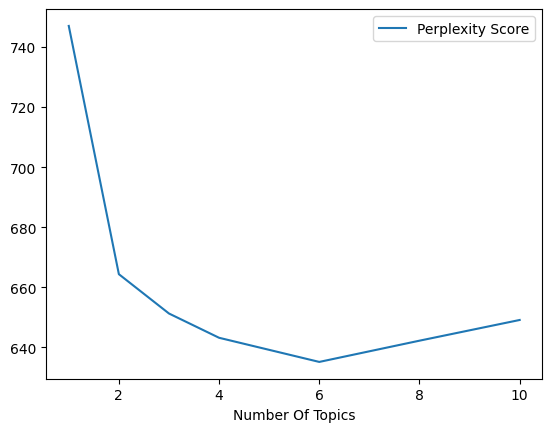

In [40]:
df_perplexity.plot.line("Number Of Topics", "Perplexity Score")

In [41]:
# define and fit LDA model

lda = sklearn.decomposition.LatentDirichletAllocation(
    n_components=optimal_num_topics,
    learning_method="online",
    random_state=0
)
lda.fit(clean_vec1)

LatentDirichletAllocation(learning_method='online', n_components=6,
                          random_state=0)

In [42]:
# output matrix
# h: docs to topics

lda_transform = lda.transform(clean_vec1)
print(lda_transform.shape)
print(lda_transform)

(18153, 6)
[[0.26431448 0.00834453 0.0735786  0.00834892 0.0083477  0.63706577]
 [0.0166748  0.01692203 0.16758748 0.01684089 0.7652382  0.01673659]
 [0.39935009 0.00316345 0.28920322 0.00316133 0.00316675 0.30195517]
 ...
 [0.01395184 0.01392955 0.01394783 0.01402043 0.3870927  0.55705764]
 [0.01853369 0.01861772 0.01857826 0.16424361 0.01860465 0.76142208]
 [0.00491761 0.13450086 0.00492688 0.16757674 0.30631427 0.38176365]]


In [43]:
# output matrix
# w: words to topics

lda_components = lda.components_
print(lda_components.shape)
print(lda_components)

(6, 1000)
[[5.80361931e+02 1.84056620e+01 1.75119392e-01 ... 6.35179894e+02
  1.68152359e-01 2.07219150e+02]
 [1.67042355e-01 4.79677964e+01 2.18698833e-01 ... 1.68275014e-01
  1.67409509e-01 1.68087904e-01]
 [1.66782630e-01 4.42031668e+00 4.08963628e+01 ... 3.53964439e+02
  2.43317913e+02 1.70182862e-01]
 [1.66869313e-01 1.70747758e-01 3.19086552e+01 ... 2.83717658e+01
  1.67253586e-01 1.68589580e-01]
 [1.68542569e-01 4.01446613e+01 1.68330217e-01 ... 1.68888144e-01
  1.68042502e-01 1.67588245e-01]
 [1.66932646e-01 2.00974150e+02 1.67161705e+02 ... 8.93755030e+02
  1.68385059e-01 2.07749811e+02]]


In [44]:
# define function to reformat output matrices into easily readable tables

def get_topics(mod, vec, names, docs, ndocs, nwords):
    # word to topic matrix
    W = mod.components_
    W_norm = W / W.sum(axis=1)[:, numpy.newaxis]
    # topic to document matrix
    H = mod.transform(vec)
    
    W_dict = {}
    H_dict = {}
    
    for tpc_idx, tpc_val in enumerate(W_norm):
        topic = "Topic{}".format(tpc_idx)
        
        # formatting w
        W_indices = tpc_val.argsort()[::-1][:nwords]
        W_names_values = [
            (round(tpc_val[j], 4), names[j]) 
            for j in W_indices
        ]
        W_dict[topic] = W_names_values
        
        # formatting h
        H_indices = H[:, tpc_idx].argsort()[::-1][:ndocs]
        H_names_values = [
            (round(H[:, tpc_idx][j], 4), docs[j]) 
            for j in H_indices
        ]
        H_dict[topic] = H_names_values
        
    W_df = pandas.DataFrame(
        W_dict, 
        index=["Word" + str(i) for i in range(nwords)]
    )
    H_df = pandas.DataFrame(
        H_dict,
        index=["Doc" + str(i) for i in range(ndocs)]
    )
        
    return (W_df, H_df)

In [45]:
# run function

W_df, H_df = get_topics(
    mod=lda,
    vec=clean_vec1,
    names=feature_names_vec1,
    docs=raw,
    ndocs=number_docs, 
    nwords=number_words
)

In [46]:
# word-topic table

print(W_df)

                     Topic0                 Topic1                Topic2  \
Word0    (0.0298, armenian)  (0.0247, information)      (0.0266, people)   
Word1       (0.0189, first)       (0.0178, system)       (0.0182, state)   
Word2      (0.0155, player)    (0.0141, available)  (0.0174, government)   
Word3  (0.0143, university)        (0.0132, phone)       (0.0172, right)   
Word4       (0.0124, years)       (0.0127, number)       (0.0133, child)   
Word5      (0.0123, period)        (0.012, access)     (0.01, president)   
Word6       (0.0123, april)      (0.0112, provide)       (0.0093, would)   
Word7          (0.012, the)       (0.011, message)       (0.0087, woman)   
Word8     (0.0115, turkish)        (0.0105, group)     (0.0083, country)   
Word9          (0.0114, 25)        (0.0102, email)      (0.0074, israel)   

                    Topic3              Topic4               Topic5  
Word0  (0.0197, christian)     (0.0185, drive)      (0.0378, would)  
Word1     (0.0181, peop

In [47]:
# document-topic table

print(H_df)

                                                 Topic0  \
Doc0  (0.9881, \nSeconded.   I cycle to work each da...   
Doc1  (0.9841, Betty Harvey writes,\n\n\nThis, simpl...   
Doc2  (0.9841, []\n\n\t"I read an article in the 3/2...   
Doc3  (0.9768, We are searching for one or two instr...   
Doc4  (0.9747, \nA(>  Can anyone tell me if a bloodc...   
Doc5  (0.9667, I am wanting to upgrade from a 386SX-...   
Doc6  (0.9666, \nHey Valentine, I don't see Boston w...   
Doc7  (0.9638, Does X11R5 support the graphics accel...   
Doc8  (0.9603, You will need Driver ver 3.5.2 to wor...   
Doc9  (0.9469, \nNo!  Distribution keywords are case...   

                                                 Topic1  \
Doc0  (0.9352, 2 Kenwood KS-H51 150-Watt Floor-stand...   
Doc1  (0.9299, Disclaimer -- This is for fun.\n\nIn ...   
Doc2  (0.9162, \nActually, I was hoping for Barry Bo...   
Doc3  (0.9073, \n\n\nThere are several products you ...   
Doc4  (0.9071, Hey guys!\nI run twm and would like t...

In [48]:
# iterative visualization
# featuring pca biplot and histogram
lda_plot = prepare(lda, clean_vec1, vectorizer1, R=10, n_jobs=1)
pyLDAvis.display(lda_plot)

In [49]:
# define functiont to fit and plot t-SNE model

def plot_tsne(data, threshold):
    # filter data according to threshold
    index_meet_threshold = numpy.amax(data, axis=1) >= threshold
    lda_transform_filt = data[index_meet_threshold]
    
    # fit tsne model
    # x-d -> 2-d, x = number of topics
    tsne = sklearn.manifold.TSNE(
        n_components=2, 
        verbose=0, 
        random_state=0, 
        angle=0.5, 
        init='pca'
    )
    tsne_fit = tsne.fit_transform(lda_transform_filt)
    
    # most probable topic for each headline
    most_prob_topic = []
    for i in range(tsne_fit.shape[0]):
        most_prob_topic.append(lda_transform_filt[i].argmax())
    
    print("LENGTH:\n{}\n".format(len(most_prob_topic)))

    unique, counts = numpy.unique(
        numpy.array(most_prob_topic), 
        return_counts=True
    )

    print("COUNTS:\n{}\n".format(numpy.asarray((unique, counts)).T))
    
    # make plot
    color_list = ['b', 'g', 'r', 'c', 'm', 'y', 'k']

    for i in list(set(most_prob_topic)):
        indices = [idx for idx, val in enumerate(most_prob_topic) if val == i]
        matplotlib.pyplot.scatter(
            x=tsne_fit[indices, 0], 
            y=tsne_fit[indices, 1], 
            s=0.5, 
            c=color_list[i], 
            label='Topic' + str(i),
            alpha=0.25
        )

    matplotlib.pyplot.xlabel('x-tsne')
    matplotlib.pyplot.ylabel('y-tsne')
    matplotlib.pyplot.legend(markerscale=10)

LENGTH:
3585

COUNTS:
[[   0  105]
 [   1  113]
 [   2  270]
 [   3  290]
 [   4 1491]
 [   5 1316]]



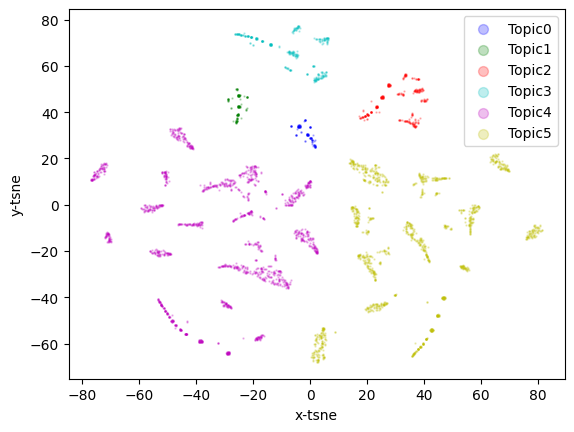

In [50]:
plot_tsne(data=lda_transform, threshold=0.75)

In [51]:
# rerun LDA model using number of topics equal to 5

lda4 = sklearn.decomposition.LatentDirichletAllocation(
    n_components=5,  # number of topics data suggests
    learning_method="online",
    random_state=0
)
lda4.fit(clean_vec1)

LatentDirichletAllocation(learning_method='online', n_components=5,
                          random_state=0)

In [52]:
# run function to output raw matrices in nice table format

W_df4, H_df4 = get_topics(
    mod=lda4,
    vec=clean_vec1,
    names=feature_names_vec1,
    docs=raw,
    ndocs=number_docs, 
    nwords=number_words
)

In [53]:
# word-topic table

print(W_df4)

                     Topic0                 Topic1               Topic2  \
Word0    (0.0196, armenian)       (0.0243, system)     (0.0265, people)   
Word1       (0.0123, state)  (0.0162, information)      (0.0189, would)   
Word2       (0.0116, space)        (0.0124, phone)      (0.0119, think)   
Word3      (0.0101, report)      (0.0121, running)      (0.0116, right)   
Word4       (0.0093, april)     (0.0118, computer)    (0.0105, believe)   
Word5     (0.009, american)       (0.0118, number)   (0.0082, question)   
Word6       (0.0089, years)      (0.0117, message)  (0.0072, christian)   
Word7       (0.0089, first)       (0.0113, access)      (0.0071, state)   
Word8  (0.0087, university)          (0.0102, the)      (0.0069, claim)   
Word9    (0.0084, national)    (0.0101, available)      (0.0066, point)   

                  Topic3              Topic4  
Word0    (0.0377, would)   (0.0211, program)  
Word1    (0.0204, think)     (0.0204, drive)  
Word2     (0.017, could)     (0.0

In [54]:
# document-topic table

print(H_df4)

                                                 Topic0  \
Doc0  (0.9885, \nSeconded.   I cycle to work each da...   
Doc1  (0.9805, Yesterday I read an article from some...   
Doc2                                         (0.9789, )   
Doc3  (0.9789, \n\nDennis, I have worked on or writt...   
Doc4  (0.9789, [...]\n\nThe President is not compete...   
Doc5  (0.9776, We are searching for one or two instr...   
Doc6  (0.9756, \nA(>  Can anyone tell me if a bloodc...   
Doc7  (0.9752, \tDo you have a problem with the lang...   
Doc8  (0.9679, I am wanting to upgrade from a 386SX-...   
Doc9  (0.9675, \nHey Valentine, I don't see Boston w...   

                                                 Topic1  \
Doc0  (0.9541, I am looking for GUI Builders/UIMS's ...   
Doc1  (0.9371, 2 Kenwood KS-H51 150-Watt Floor-stand...   
Doc2  (0.9322, \nHuh?    Did this guy just invent wr...   
Doc3  (0.9261, \nAnd the initiative for actual imple...   
Doc4                                         (0.9102, )

In [55]:
# iteractive visualization

lda4_plot = prepare(lda4, clean_vec1, vectorizer1, R=10, n_jobs=1)
pyLDAvis.display(lda4_plot)

In [56]:
# convert to bag of words model
# use tf-idf method this time

vectorizer2 = sklearn.feature_extraction.text.TfidfVectorizer(
    analyzer="word",
    max_df=0.5, 
    min_df=20, 
    max_features=number_features,
    smooth_idf=False
)
clean_vec2 = vectorizer2.fit_transform(clean_sentences)
print(clean_vec2[0])

  (0, 52)	0.2073013245979235
  (0, 817)	0.14942801863548263
  (0, 210)	0.19780000891241012
  (0, 641)	0.2467889926285363
  (0, 965)	0.22143921939935585
  (0, 786)	0.45870648045498313
  (0, 735)	0.24004020572236048
  (0, 101)	0.16129669575435052
  (0, 910)	0.17877520370601785
  (0, 990)	0.23800253347045228
  (0, 465)	0.24130969350939024
  (0, 379)	0.3177798455590309
  (0, 412)	0.16967674689163487
  (0, 511)	0.26451043710400585
  (0, 723)	0.2258938566559485
  (0, 192)	0.24152488150849313
  (0, 664)	0.1888026474266055


In [57]:
feature_names_vec2 = vectorizer2.get_feature_names()
feature_names_vec2

['25',
 'ability',
 'absolutely',
 'abuse',
 'accept',
 'access',
 'accord',
 'account',
 'across',
 'action',
 'active',
 'activity',
 'actual',
 'actually',
 'addition',
 'additional',
 'address',
 'administration',
 'admit',
 'advance',
 'advantage',
 'advice',
 'affect',
 'agency',
 'agent',
 'agree',
 'algorithm',
 'allow',
 'almost',
 'alone',
 'along',
 'already',
 'alternative',
 'although',
 'always',
 'amendment',
 'america',
 'american',
 'among',
 'amount',
 'analysis',
 'and',
 'andor',
 'angeles',
 'animal',
 'announce',
 'anonymous',
 'another',
 'answer',
 'anybody',
 'anyone',
 'anything',
 'anyway',
 'apparently',
 'appear',
 'apple',
 'application',
 'apply',
 'appreciate',
 'approach',
 'appropriate',
 'april',
 'archive',
 'argue',
 'argument',
 'armenia',
 'armenian',
 'around',
 'article',
 'asking',
 'associate',
 'assume',
 'atheist',
 'attack',
 'attempt',
 'attention',
 'attitude',
 'author',
 'authority',
 'available',
 'average',
 'avoid',
 'aware',
 'azerb

In [58]:
# define and fit nmf model

nmf = sklearn.decomposition.NMF(
    n_components=5,
    init="nndsvda",
    solver="mu",
    beta_loss="frobenius",
    random_state=0, 
    alpha=0.1, 
    l1_ratio=0.5
)
nmf.fit(clean_vec2)

NMF(alpha=0.1, init='nndsvda', l1_ratio=0.5, n_components=5, random_state=0,
    solver='mu')

In [59]:
# run function to produce nice output tables

W_df, H_df = get_topics(
    mod=nmf,
    vec=clean_vec2,
    names=feature_names_vec2,
    docs=raw,
    ndocs=number_docs, 
    nwords=number_words
)

In [60]:
# word-topic table

print(W_df)

                  Topic0              Topic1                Topic2  \
Word0    (0.0124, think)    (0.039, windows)       (0.3123, would)   
Word1   (0.0124, people)    (0.025, problem)      (0.1407, anyone)   
Word2    (0.0078, right)   (0.0249, program)  (0.0383, appreciate)   
Word3    (0.0063, could)    (0.0234, system)       (0.0278, could)   
Word4    (0.0059, point)    (0.0201, driver)      (0.0182, wonder)   
Word5  (0.0058, believe)     (0.0172, using)     (0.0151, looking)   
Word6    (0.0057, first)   (0.0158, version)     (0.0142, greatly)   
Word7   (0.0054, really)  (0.0132, software)       (0.013, thanks)   
Word8    (0.0049, going)    (0.0112, window)  (0.012, information)   
Word9    (0.0048, still)     (0.0108, image)     (0.0102, someone)   

                     Topic3                Topic4  
Word0       (0.2786, drive)      (0.1406, please)  
Word1      (0.0386, floppy)       (0.1031, email)  
Word2  (0.0338, controller)       (0.052, thanks)  
Word3      (0.0196, f

In [61]:
# document-topic table

print(H_df)

                                                 Topic0  \
Doc0  (0.0667, %I say buy out Henderson's contract a...   
Doc1  (0.0645, Hello:\n\nDo you know about a mouse o...   
Doc2  (0.0638, \n\nThe main effect of the spherical ...   
Doc3  (0.0632, -----BEGIN PGP SIGNED MESSAGE-----\n\...   
Doc4  (0.062, Apple IIgs\nImagewriter II COLOR print...   
Doc5                                         (0.0612, )   
Doc6  (0.059, \n: Are you saying that their was a ph...   
Doc7  (0.0583, \nMy god, how many chances do they ge...   
Doc8  (0.058, d88-jwa@hemul.nada.kth.se (Jon Wtte) w...   
Doc9                                   (0.0577, \n\n\n)   

                                                 Topic1  \
Doc0  (0.0951,  \n\n\n\n\nWait a minute.  If I read ...   
Doc1  (0.0863, # # Unfortunately, homosexuals don't ...   
Doc2  (0.0862, \nI agree.  Home runs off Clemens are...   
Doc3  (0.0844, \nHow is it ever going to be an Off- ...   
Doc4                                         (0.0827, )

In [62]:
# output raw document-topic matrix for t-SNE plot

nmf_transform = nmf.transform(clean_vec2)
print(nmf_transform.shape)
print(nmf_transform)

(18153, 5)
[[1.94181368e-02 1.25898568e-08 6.84352907e-13 9.13470788e-09
  2.34005294e-20]
 [2.58217913e-06 1.14520386e-02 9.79428367e-03 1.33451205e-09
  2.15023288e-02]
 [2.68862438e-02 1.00207608e-06 2.30610420e-22 2.44384964e-09
  1.89865037e-13]
 ...
 [5.84038205e-03 9.46888340e-03 3.56355329e-23 3.30699097e-03
  2.40082606e-20]
 [1.79299388e-02 6.34613545e-09 3.34630172e-23 1.04577634e-17
  1.74309505e-25]
 [1.29400370e-02 2.06617986e-02 7.54107525e-03 9.34691834e-04
  6.69866827e-04]]


LENGTH:
18153

COUNTS:
[[    0 10746]
 [    1  3358]
 [    2  1754]
 [    3   702]
 [    4  1593]]



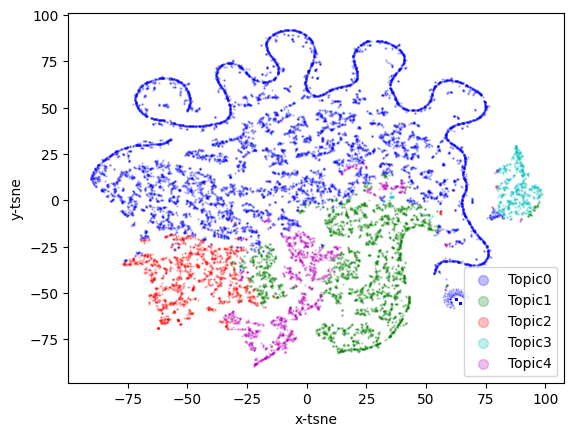

In [63]:
# run function to produce t-SNE plot

plot_tsne(data=nmf_transform, threshold=0)